In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import random
import pathlib
import itertools
from glob import glob


import tensorflow as tf

print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

from tensorflow import keras

from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model, Model, save_model
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from scipy.ndimage import distance_transform_edt

import cv2
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.morphology import label

import numpy as np

from tqdm import tqdm_notebook, tnrange


2.10.1
Num GPUs Available:  1


Dataframe Creation

In [2]:
def create_df(data_dir):
    images_paths = []
    masks_paths = glob(f"{data_dir}/*/*_mask*")

    for i in masks_paths:
        images_paths.append(i.replace("_mask",""))

    df = pd.DataFrame(data = {'images_paths':images_paths, 'masks_paths':masks_paths})

    return df

def split_df(df):
    train_df, dummy_df = train_test_split(df, train_size=0.8)
    valid_df, test_df = train_test_split(dummy_df, train_size=0.5)

    return train_df, valid_df, test_df


Image Generators and Augmentation Functions

In [11]:
def create_generators(df, aug_dict):
    img_size = (256, 256)
    batch_size = 4

    img_gen = ImageDataGenerator(**aug_dict)
    msk_gen = ImageDataGenerator(**aug_dict)

    image_gen = img_gen.flow_from_dataframe(df, x_col="images_paths", class_mode=None, color_mode='rgb', target_size=img_size, batch_size=batch_size, save_to_dir=None, save_prefix=None, seed=1)

    mask_gen = msk_gen.flow_from_dataframe(df, x_col='masks_paths', class_mode=None, color_mode='grayscale', target_size=img_size, batch_size=batch_size, save_to_dir=None, save_prefix='mask', seed=1)

    gen = zip(image_gen, mask_gen)

    for (img, mask) in gen:
        img = img / 255
        mask = mask / 255
        mask[mask > 0.5] = 1
        mask[mask < 0.5] = 0

        yield img, mask

U-NET Architecture

In [12]:
def unet(input_size=(256, 256, 3)):
    inputs = Input(input_size)
    conv1 = Conv2D(filters=64, kernel_size=(3, 3), padding='same')(inputs)
    bn1 = Activation('relu')(conv1)
    conv1 = Conv2D(filters=64, kernel_size=(3, 3), padding='same')(bn1)
    bn1 = BatchNormalization(axis=3)(conv1)
    bn1 = Activation('relu')(bn1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(bn1)

    conv2 = Conv2D(filters=128, kernel_size=(3, 3), padding='same')(pool1)
    bn2 = Activation('relu')(conv2)
    conv2 = Conv2D(filters=128, kernel_size=(3, 3), padding='same')(bn2)
    bn2 = BatchNormalization(axis=3)(conv2)
    bn2 = Activation("relu")(bn2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(bn2)

    conv3 = Conv2D(filters=256, kernel_size=(3, 3), padding='same')(pool2)
    bn3 = Activation("relu")(conv3)
    conv3 = Conv2D(filters=256, kernel_size=(3, 3), padding='same')(bn3)
    bn3 = BatchNormalization(axis=3)(conv3)
    bn3 = Activation("relu")(bn3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(bn3)

    conv4 = Conv2D(filters=512, kernel_size=(3, 3), padding='same')(pool3)
    bn4 = Activation('relu')(conv4)
    conv4 = Conv2D(filters=512, kernel_size=(3, 3), padding='same')(bn4)
    bn4 = BatchNormalization(axis=3)(conv4)
    bn4 = Activation("relu")(bn4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(bn4)

    conv5 = Conv2D(filters=1024, kernel_size=(3, 3), padding='same')(pool4)
    bn5 = Activation('relu')(conv5)
    conv5 = Conv2D(filters=1024, kernel_size=(3, 3), padding='same')(bn5)
    bn5 = BatchNormalization(axis=3)(conv5)
    bn5 = Activation("relu")(bn5)



    up6 = concatenate([Conv2DTranspose(512, kernel_size=(2, 2), strides=(2, 2), padding='same')(bn5), conv4], axis=3)
    conv6 = Conv2D(filters=512, kernel_size=(3, 3), padding='same')(up6)
    bn6 = Activation('relu')(conv6)
    conv6 = Conv2D(filters=512, kernel_size=(3, 3), padding='same')(bn6)
    bn6 = BatchNormalization(axis=3)(conv6)
    bn6 = Activation("relu")(bn6)

    up7 = concatenate([Conv2DTranspose(256, kernel_size=(2, 2), strides=(2, 2), padding='same')(bn6), conv3], axis=3)
    conv7 = Conv2D(filters=256, kernel_size=(3, 3), padding='same')(up7)
    bn7 = Activation('relu')(conv7)
    conv7 = Conv2D(filters=256, kernel_size=(3, 3), padding='same')(bn7)
    bn7 = BatchNormalization(axis=3)(conv7)
    bn7 = Activation("relu")(bn7)

    up8 = concatenate([Conv2DTranspose(128, kernel_size=(2, 2), strides=(2, 2), padding='same')(bn7), conv2], axis=3)
    conv8 = Conv2D(filters=128, kernel_size=(3, 3), padding='same')(up8)
    bn8 = Activation('relu')(conv8)
    conv8 = Conv2D(filters=128, kernel_size=(3, 3), padding='same')(bn8)
    bn8 = BatchNormalization(axis=3)(conv8)
    bn8 = Activation("relu")(bn8)

    up9 = concatenate([Conv2DTranspose(64, kernel_size=(2, 2), strides=(2, 2), padding='same')(bn8), conv1], axis=3)
    conv9 = Conv2D(filters=64, kernel_size=(3, 3), padding='same')(up9)
    bn9 = Activation('relu')(conv9)
    conv9 = Conv2D(filters=64, kernel_size=(3, 3), padding='same')(bn9)
    bn9 = BatchNormalization(axis=3)(conv9)
    bn9 = Activation("relu")(bn9)

    conv10 = Conv2D(filters=1, kernel_size=(1, 1), activation="sigmoid")(bn9)

    return Model(inputs=inputs, outputs=conv10)





Training

In [25]:
#function for creating dice coefficient
def dice_coef(y_true, y_pred, smooth=100):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)
    return (2 * intersection + smooth)/ (union + smooth)


#function for creating dice loss
def dice_loss(y_true, y_pred, smooth=100):
    return -dice_coef(y_true, y_pred, smooth=smooth)

def weighted_ce_loss(y_true, y_pred, imbalance_weights=10.0, geometry_weight_factor=5.0):
    y_true_4d = y_true
    y_pred_4d = y_pred

    ce = K.binary_crossentropy(y_true_4d, y_pred_4d)
    weights_imbalance = y_true_4d * imbalance_weights * (1.0 - y_true_4d)

    kernel = K.constant([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype='float32')
    kernel = K.reshape(kernel, (3, 3, 1, 1))
    edges = K.abs(K.conv2d(y_pred_4d, kernel, padding='same'))
    edges = K.clip(edges, 0, 1)

    geometry_weights = K.switch(K.equal(y_true_4d, 0), geometry_weight_factor*(1-edges), K.ones_like(y_true_4d))

    weights = weights_imbalance*geometry_weights
    weighted_ce = ce*weights
    return K.mean(weighted_ce)

def combined_weighted_loss(y_true, y_pred, smooth=100, alpha=0.5):
    wce = weighted_ce_loss(y_true, y_pred)
    dice = 1- dice_coef(y_true, y_pred, smooth=smooth)
    return alpha*wce + (1-alpha)*dice

 #function for creating iou coefficient
def iou_coefficient(y_true, y_pred, smooth=100):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou




In [14]:
#function to show images of sample
def show_images(images, masks):
    plt.figure(figsize=(12,12))
    for i in range(25):
        plt.subplot(5,5,i+1)
        img_path = images[i]
        mask_path = masks[i]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path)
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)
        plt.axis('off')

    plt.tight_layout()
    plt.show()



In [28]:
def plots_training(hist):
    tr_acc = hist.history['accuracy']
    tr_iou = hist.history['iou_coefficient']
    tr_dice = hist.history['dice_coef']
    tr_loss = hist.history['loss']

    val_acc = hist.history['val_accuracy']
    val_iou = hist.history['val_iou_coefficient']
    val_dice = hist.history['val_dice_coef']
    val_loss = hist.history['val_loss']

    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    index_iou = np.argmax(val_iou)
    iou_highest = val_iou[index_iou]
    index_dice = np.argmax(val_dice)
    dice_highest = val_dice[index_dice]
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]

    epochs = [i+1 for i in range(len(tr_acc))]

    acc_label = f'Best epoch= {str(index_acc + 1)}'
    iou_label = f'Best epoch = {str(index_iou + 1)}'
    dice_label = f'Best epoch = {str(index_dice + 1)}'
    loss_label = f'Best epoch = {str(index_loss + 1)}'
    #Plot training history
    plt.figure(figsize=(12,12))
    plt.style.use('fivethirtyeight')

    #Plot Training Accuracy
    plt.subplot(2,2,1)
    plt.plot(epochs, tr_acc, 'r', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g',label='Validation Accuracy')
    plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    #Plot training IoU
    plt.subplot(2,2,2)
    plt.plot(epochs, tr_iou, 'r', label='Training IoU')
    plt.plot(epochs, val_iou, 'g',label='Validation IoU')
    plt.scatter(index_acc + 1, iou_highest, s=150, c='blue', label=iou_label)
    plt.title('Training and Validation IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    #Plot training Dice
    plt.subplot(2,2,3)
    plt.plot(epochs, tr_dice, 'r', label='Training Dice')
    plt.plot(epochs, val_dice, 'g',label='Validation Dice')
    plt.scatter(index_acc + 1, dice_highest, s=150, c='blue', label=dice_label)
    plt.title('Training and Validation Dice')
    plt.xlabel('Epochs')
    plt.ylabel('Dice')
    plt.legend()

    #Plot Training Loss
    plt.subplot(2,2,4)
    plt.plot(epochs, tr_loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'g',label='Validation Loss')
    plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

Dataset

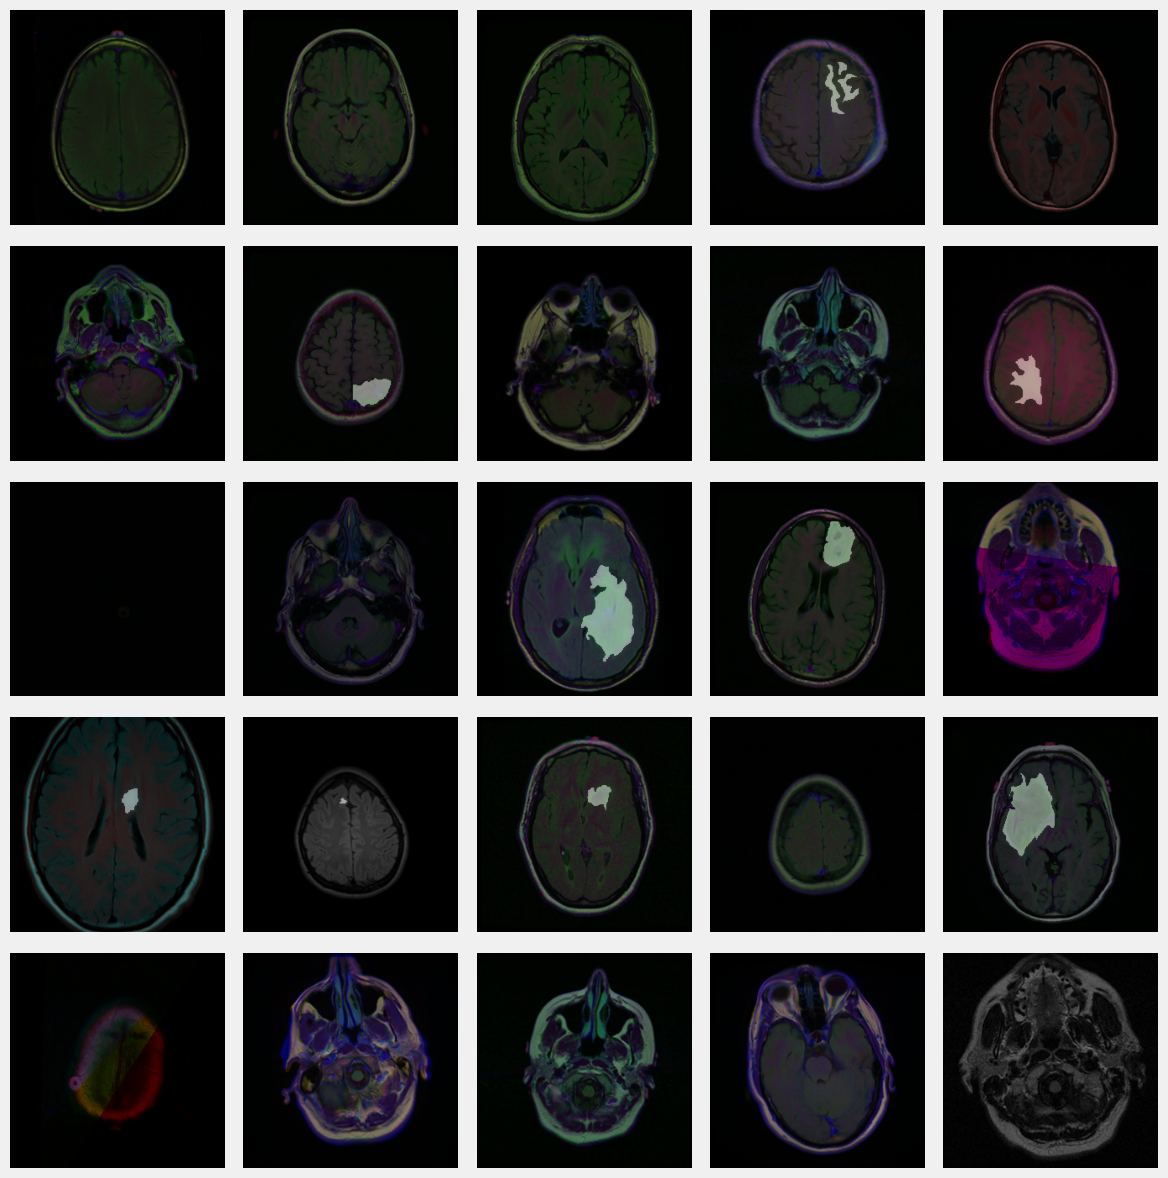

In [27]:
data_dir = r'\data\lgg-mri-segmentation\kaggle_3m'

df = create_df(data_dir)
train_df, valid_df, test_df = split_df(df)

tr_aug_dict = dict(rotation_range=0.2, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.05, zoom_range=0.1, horizontal_flip=True ,fill_mode='nearest')

train_gen = create_generators(train_df, aug_dict = tr_aug_dict)
valid_gen = create_generators(valid_df, aug_dict = {})
test_gen = create_generators(test_df, aug_dict = {})
show_images(list(train_df['images_paths']), list(train_df['masks_paths']))

U-NET Model Run

In [17]:
model = unet()
model.compile(Adamax(learning_rate=0.001), loss=lambda y_true, y_pred: combined_weighted_loss(y_true, y_pred, smooth=1, alpha=0.5), metrics=['accuracy', iou_coefficient, dice_coef])

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_19 (Conv2D)             (None, 256, 256, 64  1792        ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 activation_18 (Activation)     (None, 256, 256, 64  0           ['conv2d_19[0][0]']              
                                )                                                           

Model Training

In [18]:
epochs = 120
batch_size = 4
callbacks = [
    ModelCheckpoint('unet_weighted.keras', verbose=0, save_best_only=True),
    ReduceLROnPlateau(monitor='val_dice_coef', factor=0.5, patience=5, min_lr=1e-6, mode='max', verbose=1)
]

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // batch_size,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    validation_steps=len(valid_df) // batch_size
)

Found 3143 validated image filenames.
Found 3143 validated image filenames.
Epoch 1/120
785/785 [==============================] - ETA: 0s - loss: 0.3332 - accuracy: 0.9774 - iou_coefficient: 0.2561 - dice_coef: 0.3441Found 393 validated image filenames.
Found 393 validated image filenames.
785/785 [==============================] - 183s 222ms/step - loss: 0.3332 - accuracy: 0.9774 - iou_coefficient: 0.2561 - dice_coef: 0.3441 - val_loss: 0.3467 - val_accuracy: 0.9913 - val_iou_coefficient: 0.3277 - val_dice_coef: 0.3986 - lr: 0.0010
Epoch 2/120
785/785 [==============================] - 181s 223ms/step - loss: 0.2646 - accuracy: 0.9902 - iou_coefficient: 0.3901 - dice_coef: 0.4861 - val_loss: 0.2716 - val_accuracy: 0.9902 - val_iou_coefficient: 0.4677 - val_dice_coef: 0.5611 - lr: 0.0010
Epoch 3/120
785/785 [==============================] - 174s 221ms/step - loss: 0.2641 - accuracy: 0.9912 - iou_coefficient: 0.4018 - dice_coef: 0.4933 - val_loss: 0.2745 - val_accuracy: 0.9825 - val_i

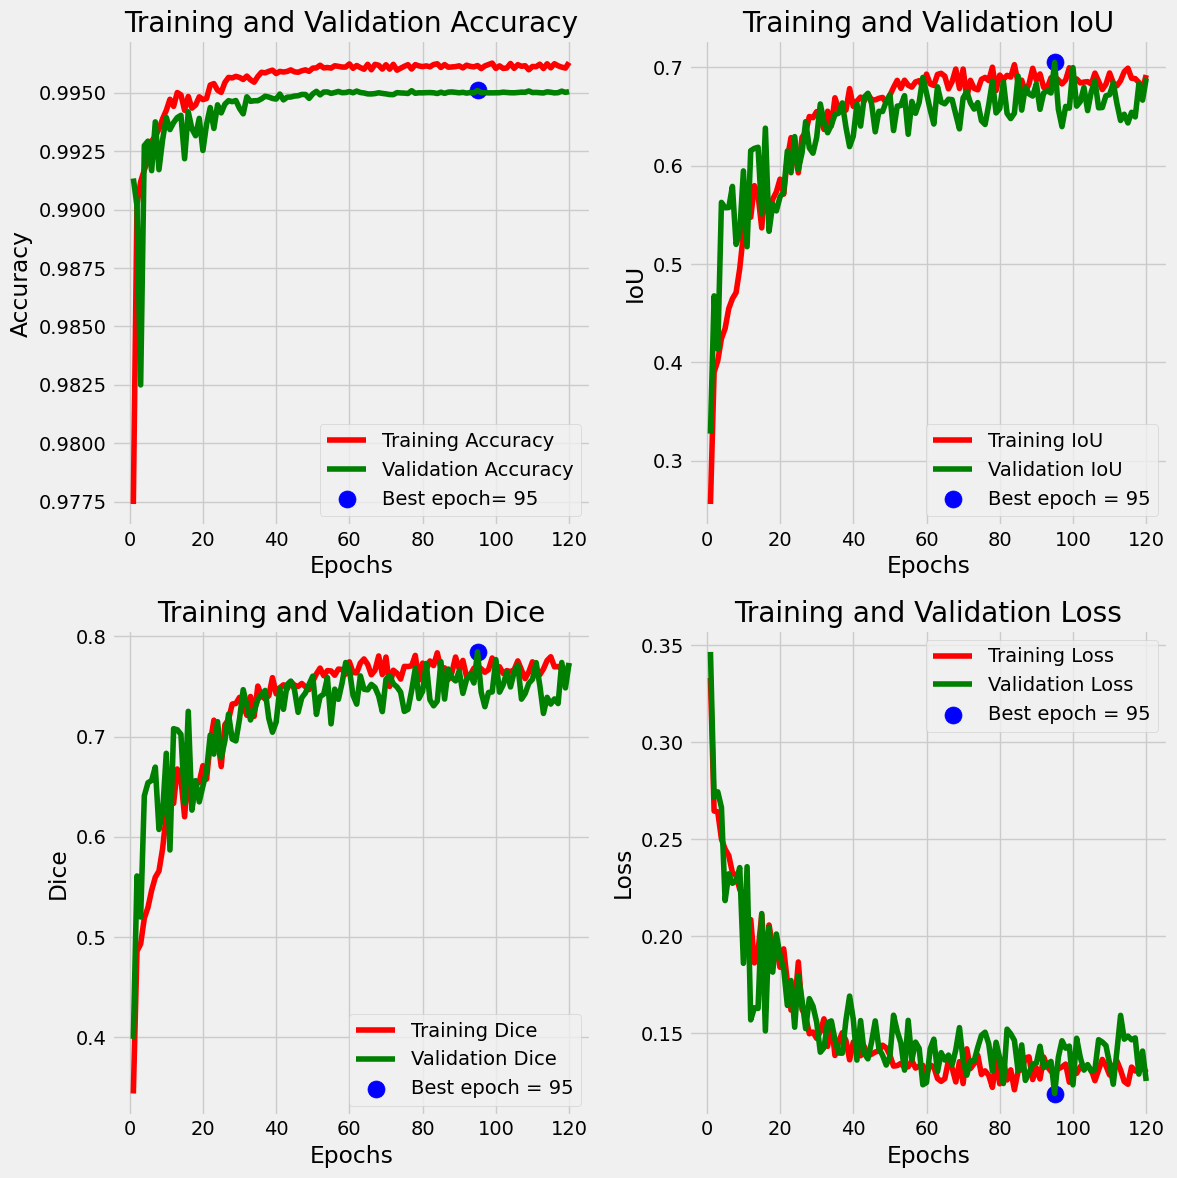

In [29]:
 plots_training(history)

Model Evaluation

In [20]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps = test_steps, verbose=1)
valid_score = model.evaluate(valid_gen, steps = test_steps, verbose=1)
test_score = model.evaluate(test_gen, steps = test_steps, verbose=1)

print("Train Loss:", train_score[0])
print("Train Accuracy:", train_score[1])
print("Train IoU:", train_score[2])
print("Train Dice:", train_score[3])
print("-"*10)

print("Validation Loss:", valid_score[0])
print("Validation Accuracy:", valid_score[1])
print("Validation IoU:", valid_score[2])
print("Validation Dice:", valid_score[3])
print("-"*10)

print("Test Loss:", test_score[0])
print("Test Accuracy:", test_score[1])
print("Test IoU:", test_score[2])
print("Test Dice:", test_score[3])

131/131 [==============================] - 11s 81ms/step - loss: 0.1370 - accuracy: 0.9952 - iou_coefficient: 0.6777 - dice_coef: 0.7585
Found 393 validated image filenames.
Found 393 validated image filenames.
131/131 [==============================] - 10s 74ms/step - loss: 0.1330 - accuracy: 0.9953 - iou_coefficient: 0.6729 - dice_coef: 0.7563
Train Loss: 0.15789932012557983
Train Accuracy: 0.9962551593780518
Train IoU: 0.6655117869377136
Train Dice: 0.7432137131690979
----------
Validation Loss: 0.1370171159505844
Validation Accuracy: 0.9951879382133484
Validation IoU: 0.6777438521385193
Validation Dice: 0.7584983110427856
----------
Test Loss: 0.1329520046710968
Test Accuracy: 0.995263397693634
Test IoU: 0.6729060411453247
Test Dice: 0.7563157677650452


Prediction

1/1 [==============================] - 0s 18ms/step


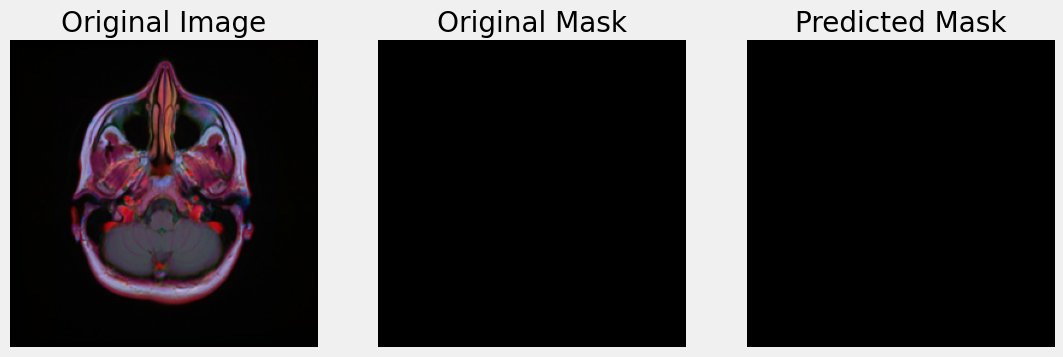

1/1 [==============================] - 0s 15ms/step


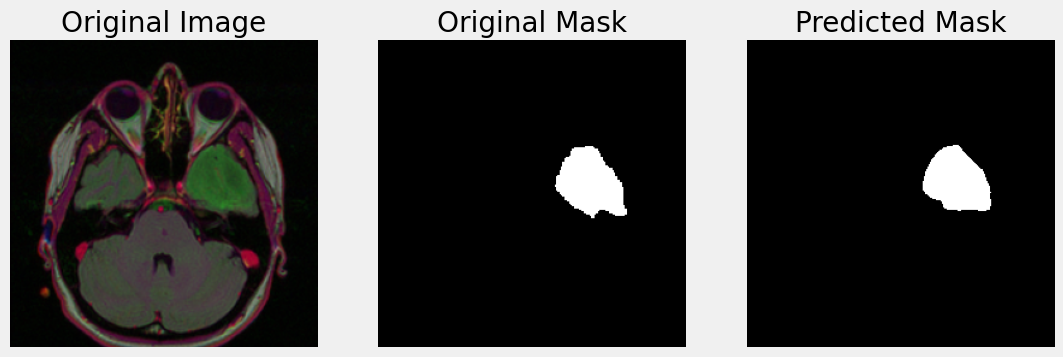

1/1 [==============================] - 0s 15ms/step


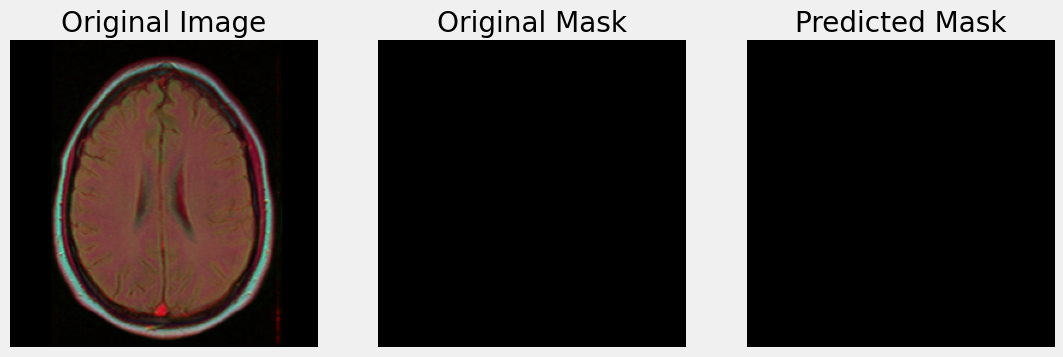

1/1 [==============================] - 0s 16ms/step


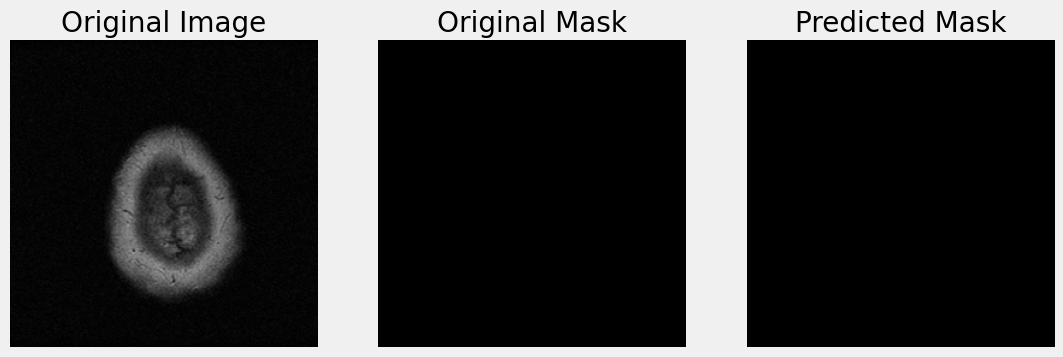

1/1 [==============================] - 0s 15ms/step


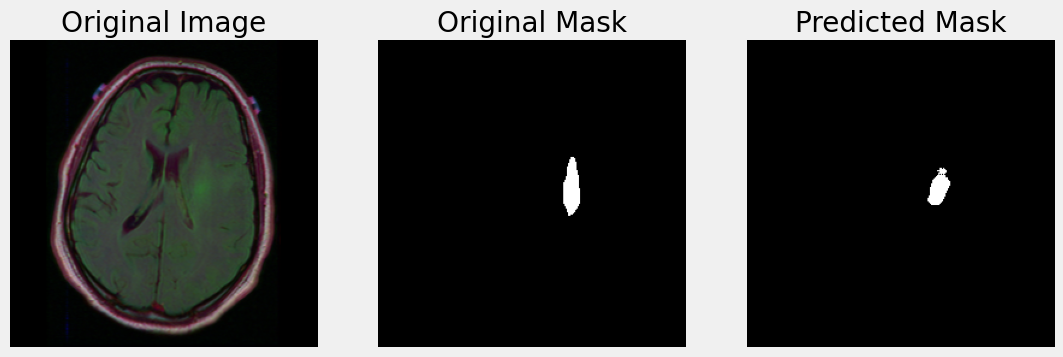

1/1 [==============================] - 0s 14ms/step


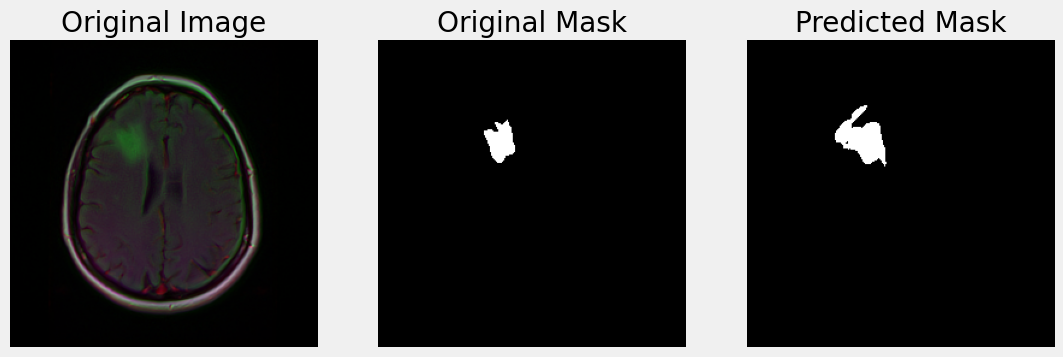

1/1 [==============================] - 0s 16ms/step


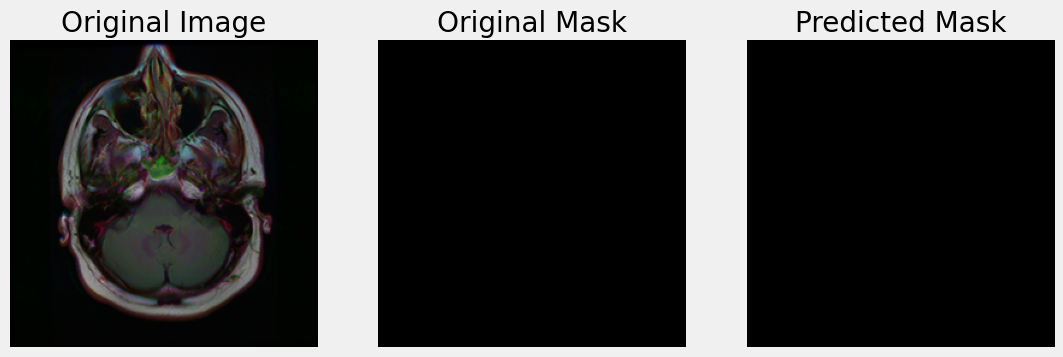

1/1 [==============================] - 0s 15ms/step


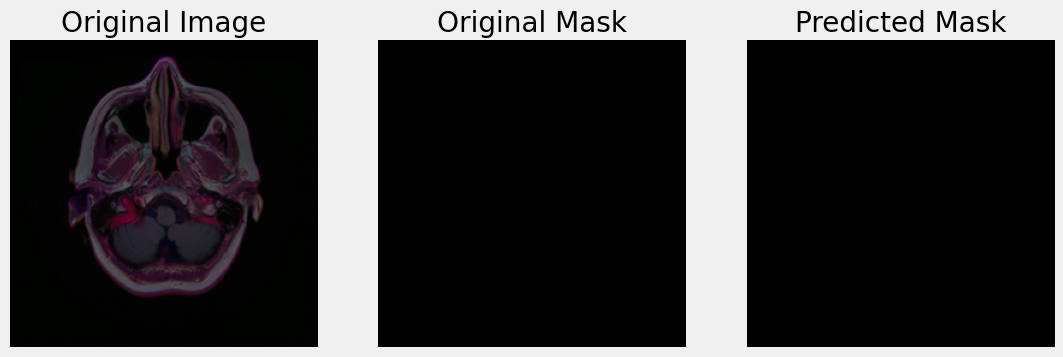

1/1 [==============================] - 0s 16ms/step


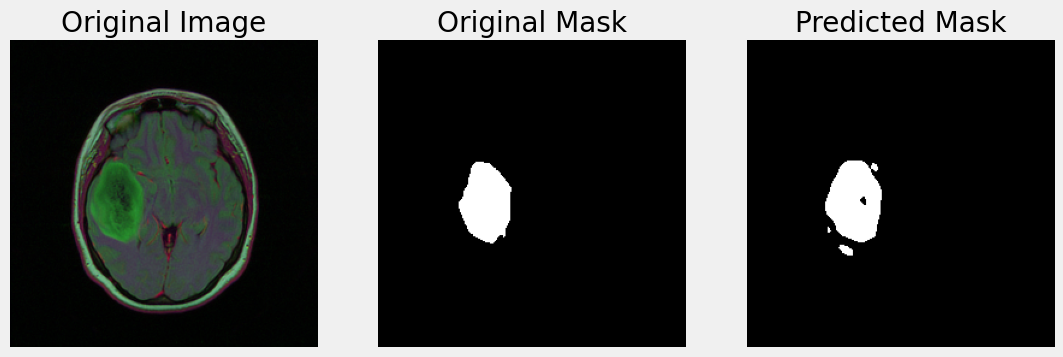

1/1 [==============================] - 0s 16ms/step


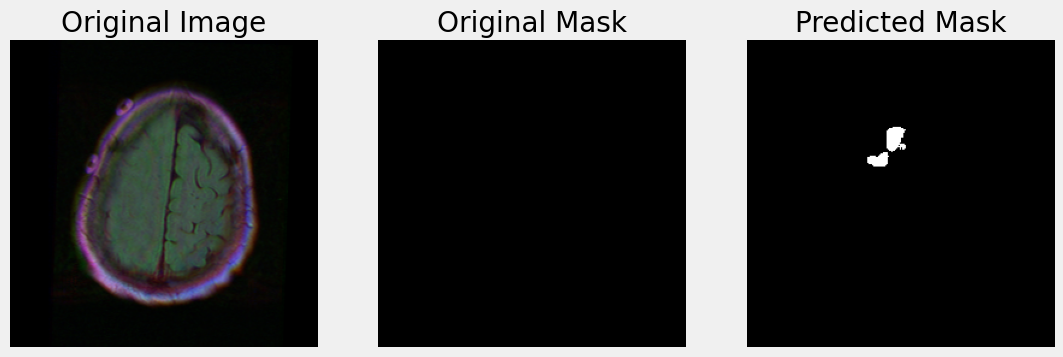

1/1 [==============================] - 0s 15ms/step


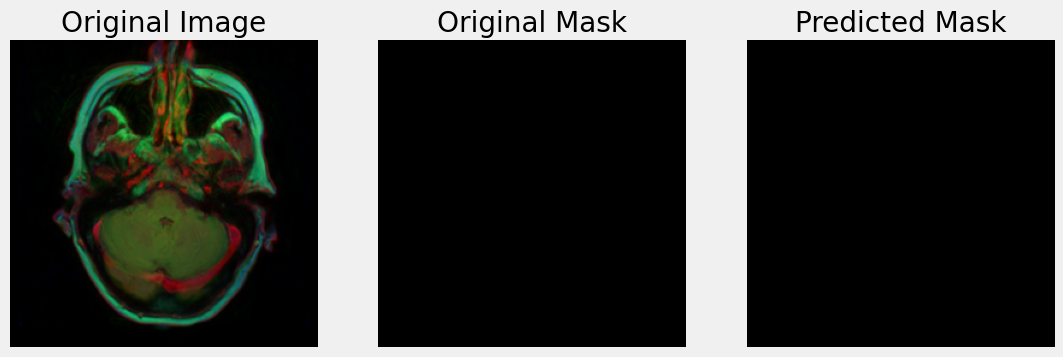

1/1 [==============================] - 0s 14ms/step


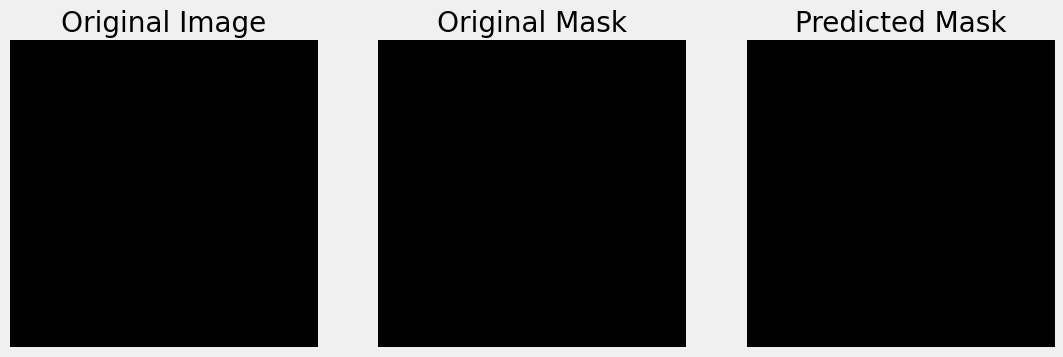

1/1 [==============================] - 0s 14ms/step


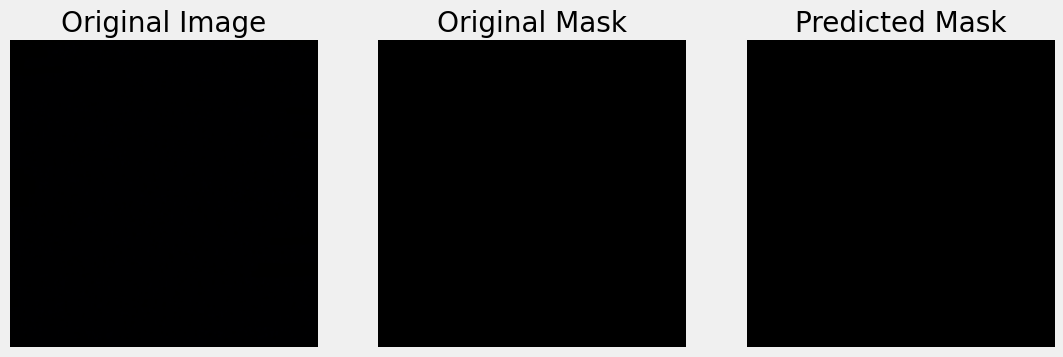

1/1 [==============================] - 0s 14ms/step


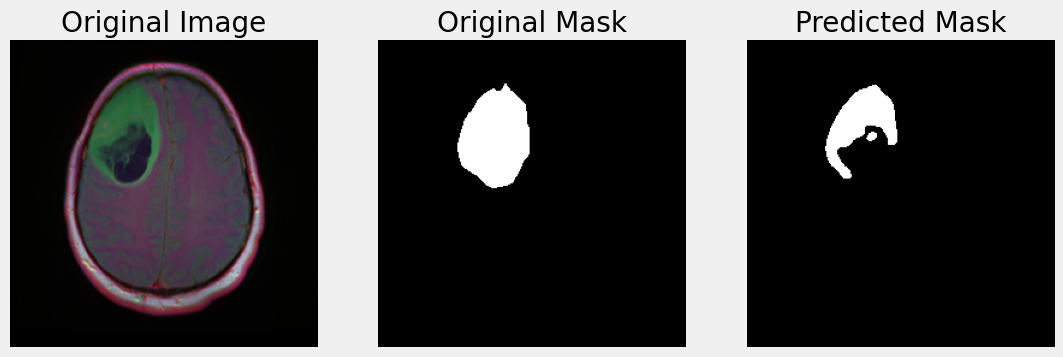

1/1 [==============================] - 0s 14ms/step


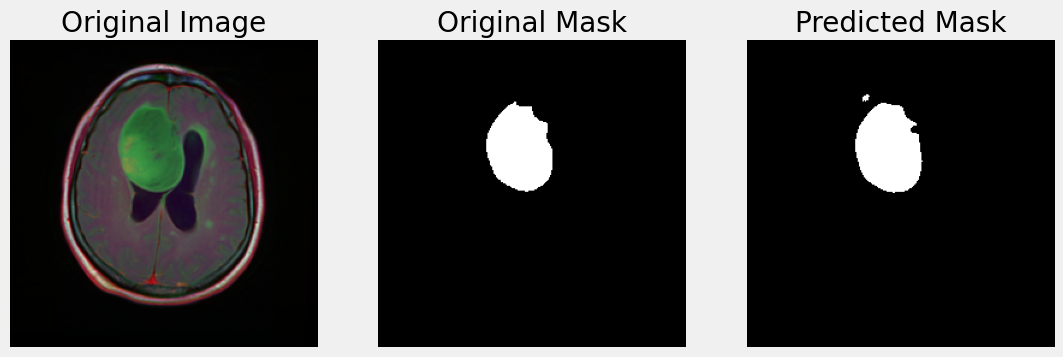

1/1 [==============================] - 0s 15ms/step


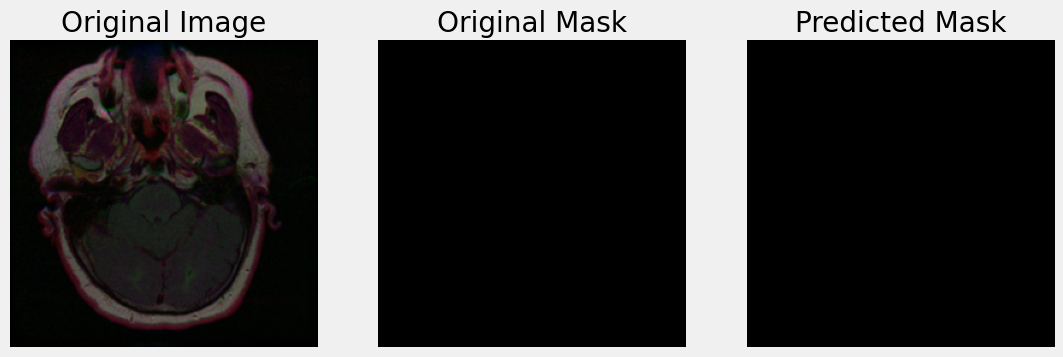

1/1 [==============================] - 0s 14ms/step


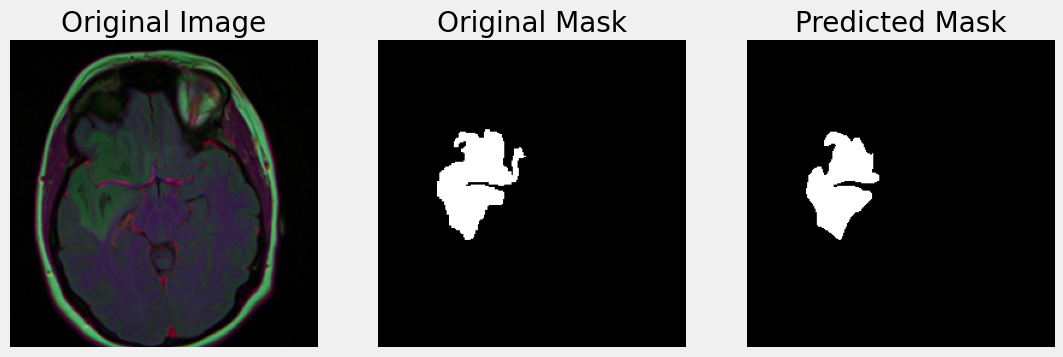

1/1 [==============================] - 0s 15ms/step


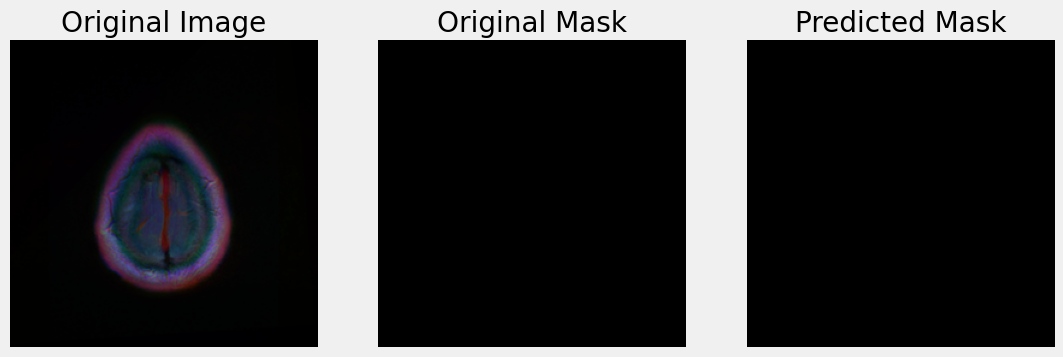

1/1 [==============================] - 0s 15ms/step


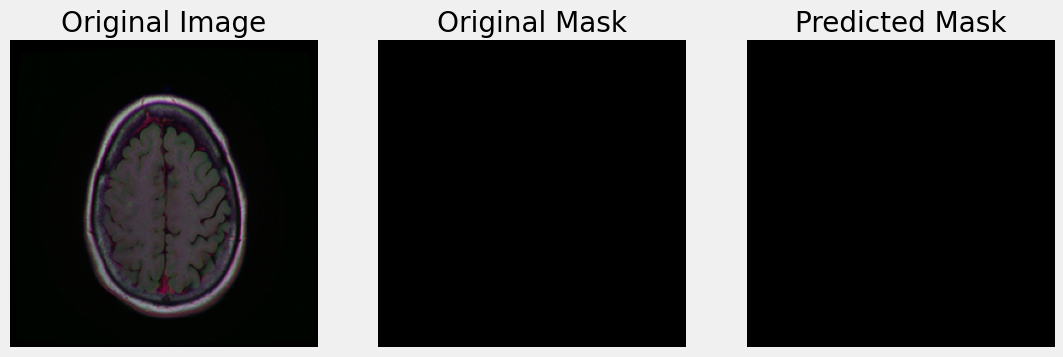

1/1 [==============================] - 0s 14ms/step


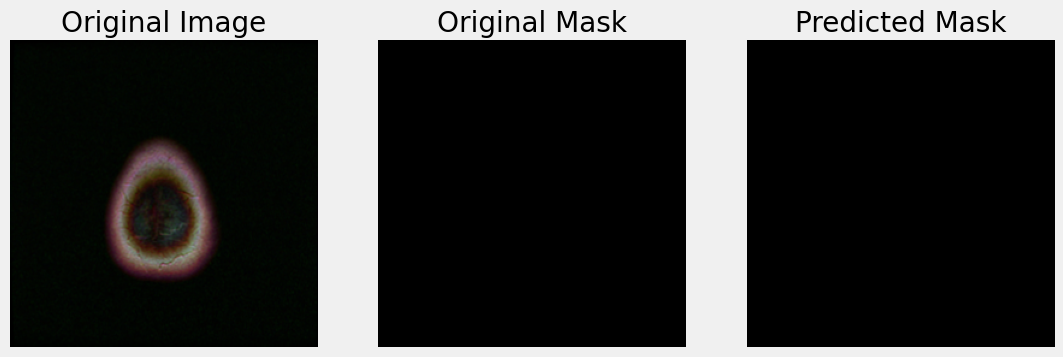

In [24]:
for i in range(20):
    index = np.random.randint(1, len(test_df.index))
    img = cv2.imread(test_df['images_paths'].iloc[index])
    img = cv2.resize(img, (256, 256))
    img = img / 255
    img = img[np.newaxis, :, :, :]

    predicted_img = model.predict(img)
    plt.figure(figsize=(12, 12))
    plt.subplot(1, 3, 1)
    plt.imshow(np.squeeze(img))
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(np.squeeze(cv2.imread(test_df['masks_paths'].iloc[index])))
    plt.axis('off')
    plt.title('Original Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(np.squeeze(predicted_img) > 0.5, cmap='gray')
    plt.axis('off')
    plt.title('Predicted Mask')

    plt.show()